In [15]:
import os
import sys
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, silhouette_score
from sklearn.neighbors import KNeighborsClassifier

try:
    import umap
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'umap-learn', '-q'])
    import umap

# Works when the notebook is run from src/ or from the project root.
NOTEBOOK_CWD = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_CWD.parent if (NOTEBOOK_CWD.parent / 'GTZAN_Data').exists() else NOTEBOOK_CWD
GTZAN_ROOT = PROJECT_ROOT / 'GTZAN_Data'
AUDIO_DIR = GTZAN_ROOT / 'genres_original'
MEL_DIR = GTZAN_ROOT / 'melspecs'
MANIFEST_CSV = GTZAN_ROOT / 'features_30_sec.csv'
MEL_MANIFEST_CSV = GTZAN_ROOT / 'gtzan_mel_manifest.csv'
CHECKPOINT_DIR = Path('checkpoints')
CHECKPOINT_DIR.mkdir(exist_ok=True)

SAMPLE_RATE = 12000
N_FFT = 512
HOP_LENGTH = 256
N_MELS = 96
CROP_LENGTH = 1366
BATCH_SIZE = 16
RANDOM_STATE = 42

print(f'Project root: {PROJECT_ROOT}')
print(f'GTZAN root:   {GTZAN_ROOT}')
print(f'Audio dir:    {AUDIO_DIR}')
print(f'Mel cache:    {MEL_DIR}')
print(f'Manifest:     {MANIFEST_CSV}')

if not AUDIO_DIR.exists():
    raise FileNotFoundError(f'Expected GTZAN WAVs at {AUDIO_DIR}')
if not MANIFEST_CSV.exists():
    raise FileNotFoundError(f'Expected GTZAN manifest at {MANIFEST_CSV}')

Project root: /Users/colbywatts/Documents/College/Spring 2026/CSC 566/csc-566-final-project
GTZAN root:   /Users/colbywatts/Documents/College/Spring 2026/CSC 566/csc-566-final-project/GTZAN_Data
Audio dir:    /Users/colbywatts/Documents/College/Spring 2026/CSC 566/csc-566-final-project/GTZAN_Data/genres_original
Mel cache:    /Users/colbywatts/Documents/College/Spring 2026/CSC 566/csc-566-final-project/GTZAN_Data/melspecs
Manifest:     /Users/colbywatts/Documents/College/Spring 2026/CSC 566/csc-566-final-project/GTZAN_Data/features_30_sec.csv


In [16]:
def crop_or_pad_mel(mel, crop_length=CROP_LENGTH):
    if mel.shape[1] > crop_length:
        start = (mel.shape[1] - crop_length) // 2
        mel = mel[:, start:start + crop_length]
    elif mel.shape[1] < crop_length:
        mel = np.pad(mel, ((0, 0), (0, crop_length - mel.shape[1])), mode='constant', constant_values=mel.min())
    return mel.astype(np.float32)


def wav_path_for_row(row):
    return AUDIO_DIR / row['label'] / row['filename']


def mel_path_for_row(row):
    return MEL_DIR / row['label'] / f"{Path(row['filename']).stem}.npy"


def wav_to_mel(wav_path):
    y, _ = librosa.load(wav_path, sr=SAMPLE_RATE, mono=True)
    mel_power = librosa.feature.melspectrogram(
        y=y,
        sr=SAMPLE_RATE,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        power=2.0,
    )
    mel_db = librosa.power_to_db(mel_power, ref=np.max)
    return crop_or_pad_mel(mel_db)


def build_mel_cache(force=False):
    df = pd.read_csv(MANIFEST_CSV)
    rows = []
    bad_files = []

    MEL_DIR.mkdir(parents=True, exist_ok=True)
    for _, row in tqdm(df.iterrows(), total=len(df), desc='Building mel cache'):
        wav_path = wav_path_for_row(row)
        mel_path = mel_path_for_row(row)
        mel_path.parent.mkdir(parents=True, exist_ok=True)

        try:
            if force or not mel_path.exists():
                mel = wav_to_mel(wav_path)
                np.save(mel_path, mel)
            rows.append({
                'filename': row['filename'],
                'label': row['label'],
                'wav_path': str(wav_path),
                'mel_path': str(mel_path),
            })
        except Exception as exc:
            bad_files.append((str(wav_path), str(exc)))

    manifest_df = pd.DataFrame(rows)
    manifest_df.to_csv(MEL_MANIFEST_CSV, index=False)

    print(f'Cached/verified mels: {len(manifest_df)}')
    if bad_files:
        print(f'Skipped unreadable files: {len(bad_files)}')
        for path, err in bad_files[:5]:
            print(f'  {path}: {err}')
    print(f'Mel manifest saved to: {MEL_MANIFEST_CSV}')
    return manifest_df


manifest_df = build_mel_cache(force=False)
display(manifest_df.head())

Building mel cache:   0%|          | 0/1000 [00:00<?, ?it/s]/var/folders/dp/18mgh39122bghz9h0h7dnv940000gn/T/ipykernel_36507/1560538226.py:19: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(wav_path, sr=SAMPLE_RATE, mono=True)
/Users/colbywatts/Documents/College/Spring 2026/CSC 566/csc-566-final-project/.venv/lib/python3.14/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Python(45694) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Building mel cache: 100%|██████████| 1000/1000 [00:02<00:00, 465.12it/s]

Cached/verified mels: 999
Skipped unreadable files: 1
  /Users/colbywatts/Documents/College/Spring 2026/CSC 566/csc-566-final-project/GTZAN_Data/genres_original/jazz/jazz.00054.wav: 
Mel manifest saved to: /Users/colbywatts/Documents/College/Spring 2026/CSC 566/csc-566-final-project/GTZAN_Data/gtzan_mel_manifest.csv


,filename,label,wav_path,mel_path
0,blues.00000.wav,blues,/Users/colbywatts/Documents/College/Spring 202...,/Users/colbywatts/Documents/College/Spring 202...
1,blues.00001.wav,blues,/Users/colbywatts/Documents/College/Spring 202...,/Users/colbywatts/Documents/College/Spring 202...
2,blues.00002.wav,blues,/Users/colbywatts/Documents/College/Spring 202...,/Users/colbywatts/Documents/College/Spring 202...
3,blues.00003.wav,blues,/Users/colbywatts/Documents/College/Spring 202...,/Users/colbywatts/Documents/College/Spring 202...
4,blues.00004.wav,blues,/Users/colbywatts/Documents/College/Spring 202...,/Users/colbywatts/Documents/College/Spring 202...


In [17]:
genres = sorted(manifest_df['label'].unique())
genre_to_idx = {genre: i for i, genre in enumerate(genres)}
idx_to_genre = {i: genre for genre, i in genre_to_idx.items()}

train_val_df, test_df = train_test_split(
    manifest_df,
    test_size=0.20,
    stratify=manifest_df['label'],
    random_state=RANDOM_STATE,
)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.20,
    stratify=train_val_df['label'],
    random_state=RANDOM_STATE,
)

print(f'Genres: {genres}')
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print('Train class counts:')
print(train_df['label'].value_counts().sort_index())


def compute_mel_stats(df):
    total = 0
    sum_x = 0.0
    sum_x2 = 0.0
    for mel_path in tqdm(df['mel_path'], desc='Computing train mel stats'):
        mel = np.load(mel_path).astype(np.float64)
        total += mel.size
        sum_x += mel.sum()
        sum_x2 += np.square(mel).sum()
    mean = sum_x / total
    var = max(sum_x2 / total - mean ** 2, 1e-8)
    return float(mean), float(np.sqrt(var))


mel_mean, mel_std = compute_mel_stats(train_df)
print(f'Train mel mean: {mel_mean:.4f} | std: {mel_std:.4f}')


class GTZANDataset(Dataset):
    def __init__(self, df, genre_to_idx, mel_mean, mel_std):
        self.df = df.reset_index(drop=True)
        self.genre_to_idx = genre_to_idx
        self.mel_mean = mel_mean
        self.mel_std = mel_std

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        mel = np.load(row['mel_path']).astype(np.float32)
        mel = (mel - self.mel_mean) / self.mel_std
        mel = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(self.genre_to_idx[row['label']], dtype=torch.long)
        return mel, label


def make_loaders(batch_size=BATCH_SIZE):
    train_ds = GTZANDataset(train_df, genre_to_idx, mel_mean, mel_std)
    val_ds = GTZANDataset(val_df, genre_to_idx, mel_mean, mel_std)
    test_ds = GTZANDataset(test_df, genre_to_idx, mel_mean, mel_std)

    loader_kwargs = dict(batch_size=batch_size, num_workers=0, pin_memory=torch.cuda.is_available())
    train_loader = DataLoader(train_ds, shuffle=True, **loader_kwargs)
    val_loader = DataLoader(val_ds, shuffle=False, **loader_kwargs)
    test_loader = DataLoader(test_ds, shuffle=False, **loader_kwargs)
    return train_loader, val_loader, test_loader


train_loader, val_loader, test_loader = make_loaders()
mels, labels = next(iter(train_loader))
print(f'Batch mels: {mels.shape} | labels: {labels.shape}')

Genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Train: 639 | Val: 160 | Test: 200
Train class counts:
label
blues        64
classical    64
country      64
disco        64
hiphop       64
jazz         63
metal        64
pop          64
reggae       64
rock         64
Name: count, dtype: int64


Computing train mel stats: 100%|██████████| 639/639 [00:00<00:00, 1131.91it/s]

Train mel mean: -39.6145 | std: 13.8895
Batch mels: torch.Size([16, 1, 96, 1366]) | labels: torch.Size([16])


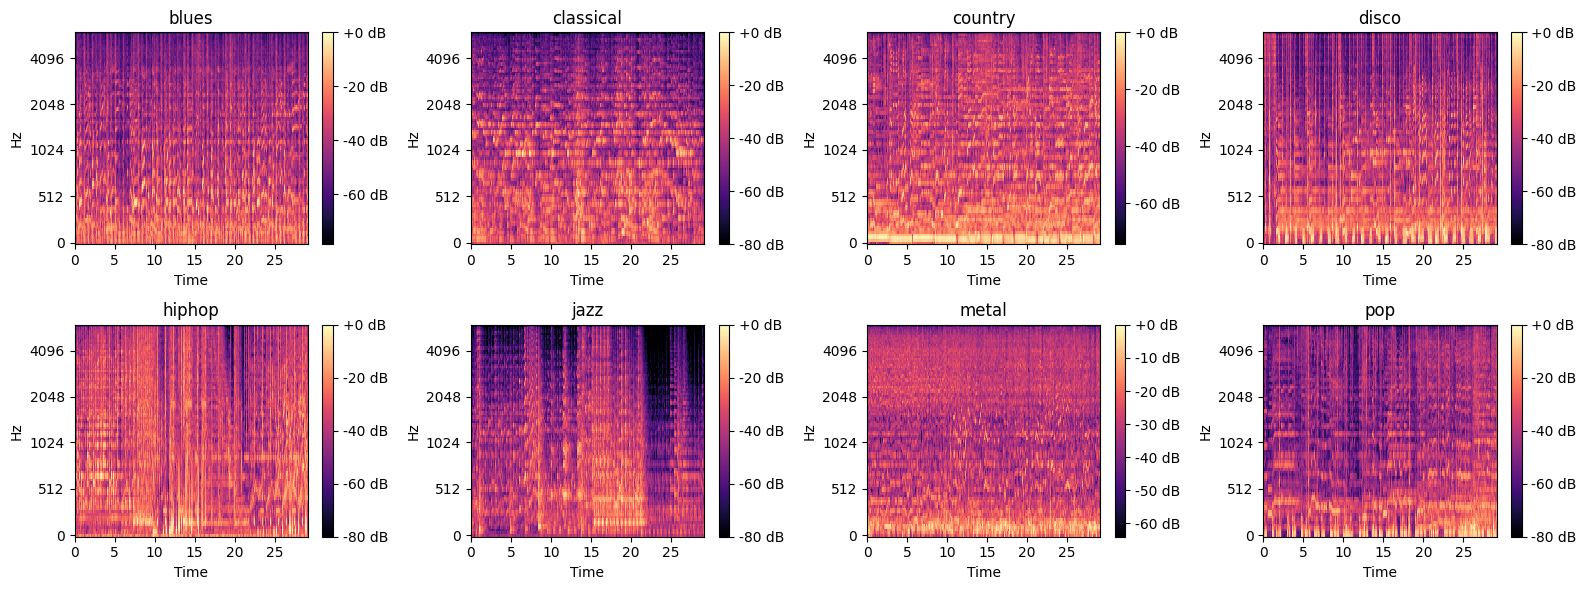

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
sample_rows = manifest_df.groupby('label', group_keys=False).head(1).head(8)

for ax, (_, row) in zip(axes.flat, sample_rows.iterrows()):
    mel = np.load(row['mel_path'])
    img = librosa.display.specshow(mel, x_axis='time', y_axis='mel', sr=SAMPLE_RATE, hop_length=HOP_LENGTH, ax=ax)
    ax.set_title(row['label'])
    fig.colorbar(img, ax=ax, format='%+2.0f dB')

plt.tight_layout()
plt.show()

In [19]:
class GenreAutoencoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 4)),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 4)),
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 4)),
        )

        self.flatten_dim = 512 * 12 * 21
        self.fc_enc = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, self.flatten_dim)

        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=(2, 4)),
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=(2, 4)),
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=(2, 4)),
            nn.Conv2d(128, 1, kernel_size=3, padding=1),
        )

    def encode(self, x):
        x = self.encoder(x)
        x = x.view(x.size(0), -1)
        return self.fc_enc(x)

    def decode(self, z):
        x = self.fc_dec(z)
        x = x.view(x.size(0), 512, 12, 21)
        x = self.decoder(x)
        if x.shape[-1] < CROP_LENGTH:
            x = nn.functional.pad(x, (0, CROP_LENGTH - x.shape[-1]))
        return x[:, :, :N_MELS, :CROP_LENGTH]

    def forward(self, x):
        z = self.encode(x)
        recon = self.decode(z)
        return recon, z


class MultiTaskGenreAutoencoder(GenreAutoencoder):
    """Same encoder/decoder as GenreAutoencoder, plus a genre head on the latent."""

    def __init__(self, latent_dim=128, num_classes=len(genres)):
        super().__init__(latent_dim)
        self.classifier = nn.Linear(latent_dim, num_classes)

    def forward(self, x):
        z = self.encode(x)
        recon = self.decode(z)
        logits = self.classifier(z)
        return recon, z, logits


_probe = MultiTaskGenreAutoencoder(latent_dim=128, num_classes=len(genres))
_probe_x = torch.randn(2, 1, N_MELS, CROP_LENGTH)
_probe_recon, _probe_z, _probe_logits = _probe(_probe_x)
print(f'Input:   {_probe_x.shape}')
print(f'Recon:   {_probe_recon.shape}')
print(f'Latent:  {_probe_z.shape}')
print(f'Logits:  {_probe_logits.shape}')


Input:   torch.Size([2, 1, 96, 1366])
Recon:   torch.Size([2, 1, 96, 1366])
Latent:  torch.Size([2, 128])
Logits:  torch.Size([2, 10])


Using device: mps


Epoch 1/20 train: 100%|██████████| 40/40 [03:44<00:00,  5.61s/it]


Epoch 1/20 | train recon 16.5838 cls 5.7631 | val recon 0.9395 cls 2.0348 acc 0.2750
  → saved checkpoints/gtzan_multitask_ae_best.pth (combined val 1.9569)


Epoch 2/20 train: 100%|██████████| 40/40 [03:08<00:00,  4.72s/it]


Epoch 2/20 | train recon 0.7905 cls 1.8917 | val recon 0.6438 cls 1.6827 acc 0.3750
  → saved checkpoints/gtzan_multitask_ae_best.pth (combined val 1.4851)


...

Epoch 19/20 train: 100%|██████████| 40/40 [02:40<00:00,  4.01s/it]


Epoch 19/20 | train recon 0.3941 cls 0.0010 | val recon 0.4422 cls 2.2019 acc 0.5625


Epoch 20/20 train: 100%|██████████| 40/40 [02:54<00:00,  4.36s/it]


Epoch 20/20 | train recon 0.3880 cls 0.0008 | val recon 0.4467 cls 2.2313 acc 0.5563


,epoch,train_recon,train_cls,val_recon,val_cls,val_acc
15,16,0.410796,0.001349,0.454534,2.177041,0.56875
16,17,0.407216,0.001187,0.444548,2.168616,0.56875
17,18,0.401034,0.001150,0.443694,2.162097,0.56875
18,19,0.394081,0.000957,0.442228,2.201883,0.56250
19,20,0.388048,0.000817,0.446661,2.231340,0.55625


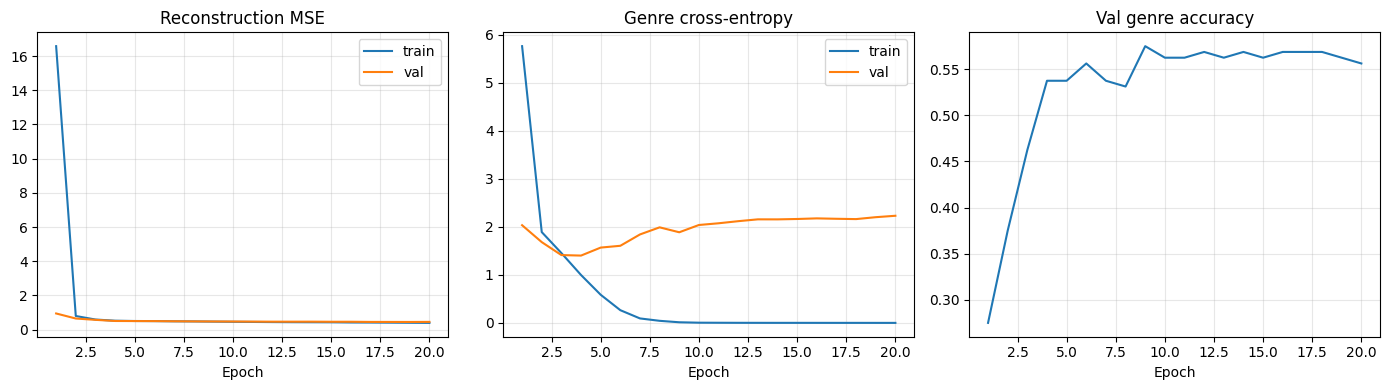

In [20]:
device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Using device: {device}')

LATENT_DIM = 128
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3
GENRE_LOSS_WEIGHT = 0.5
BEST_MODEL_PATH = CHECKPOINT_DIR / 'gtzan_multitask_ae_best.pth'

model = MultiTaskGenreAutoencoder(latent_dim=LATENT_DIM, num_classes=len(genres)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
recon_criterion = nn.MSELoss()
cls_criterion = nn.CrossEntropyLoss()

best_val_score = float('inf')
best_val_recon = float('inf')
history = []

for epoch in range(NUM_EPOCHS):
    model.train()
    train_recon = 0.0
    train_cls = 0.0

    for mels, labels in tqdm(train_loader, desc=f'Epoch {epoch + 1}/{NUM_EPOCHS} train'):
        mels = mels.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        recon, _, logits = model(mels)
        loss_recon = recon_criterion(recon, mels)
        loss_cls = cls_criterion(logits, labels)
        loss = loss_recon + GENRE_LOSS_WEIGHT * loss_cls
        loss.backward()
        optimizer.step()
        train_recon += loss_recon.item()
        train_cls += loss_cls.item()

    model.eval()
    val_recon = 0.0
    val_cls = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for mels, labels in val_loader:
            mels = mels.to(device)
            labels = labels.to(device)
            recon, _, logits = model(mels)
            val_recon += recon_criterion(recon, mels).item()
            val_cls += cls_criterion(logits, labels).item()
            val_correct += (logits.argmax(dim=1) == labels).sum().item()
            val_total += labels.size(0)

    train_recon /= len(train_loader)
    train_cls /= len(train_loader)
    val_recon /= len(val_loader)
    val_cls /= len(val_loader)
    val_acc = val_correct / val_total
    val_score = val_recon + GENRE_LOSS_WEIGHT * val_cls

    history.append({
        'epoch': epoch + 1,
        'train_recon': train_recon,
        'train_cls': train_cls,
        'val_recon': val_recon,
        'val_cls': val_cls,
        'val_acc': val_acc,
    })
    print(
        f'Epoch {epoch + 1}/{NUM_EPOCHS} | '
        f'train recon {train_recon:.4f} cls {train_cls:.4f} | '
        f'val recon {val_recon:.4f} cls {val_cls:.4f} acc {val_acc:.4f}'
    )
    if val_score < best_val_score:
        best_val_score = val_score
        best_val_recon = val_recon
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f'  → saved {BEST_MODEL_PATH} (combined val {val_score:.4f})')

history_df = pd.DataFrame(history)
display(history_df.tail())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(history_df['epoch'], history_df['train_recon'], label='train')
axes[0].plot(history_df['epoch'], history_df['val_recon'], label='val')
axes[0].set_title('Reconstruction MSE')
axes[0].legend()
axes[1].plot(history_df['epoch'], history_df['train_cls'], label='train')
axes[1].plot(history_df['epoch'], history_df['val_cls'], label='val')
axes[1].set_title('Genre cross-entropy')
axes[1].legend()
axes[2].plot(history_df['epoch'], history_df['val_acc'])
axes[2].set_title('Val genre accuracy')
axes[2].set_xlabel('Epoch')
for ax in axes[:2]:
    ax.set_xlabel('Epoch')
    ax.grid(alpha=0.3)
axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()


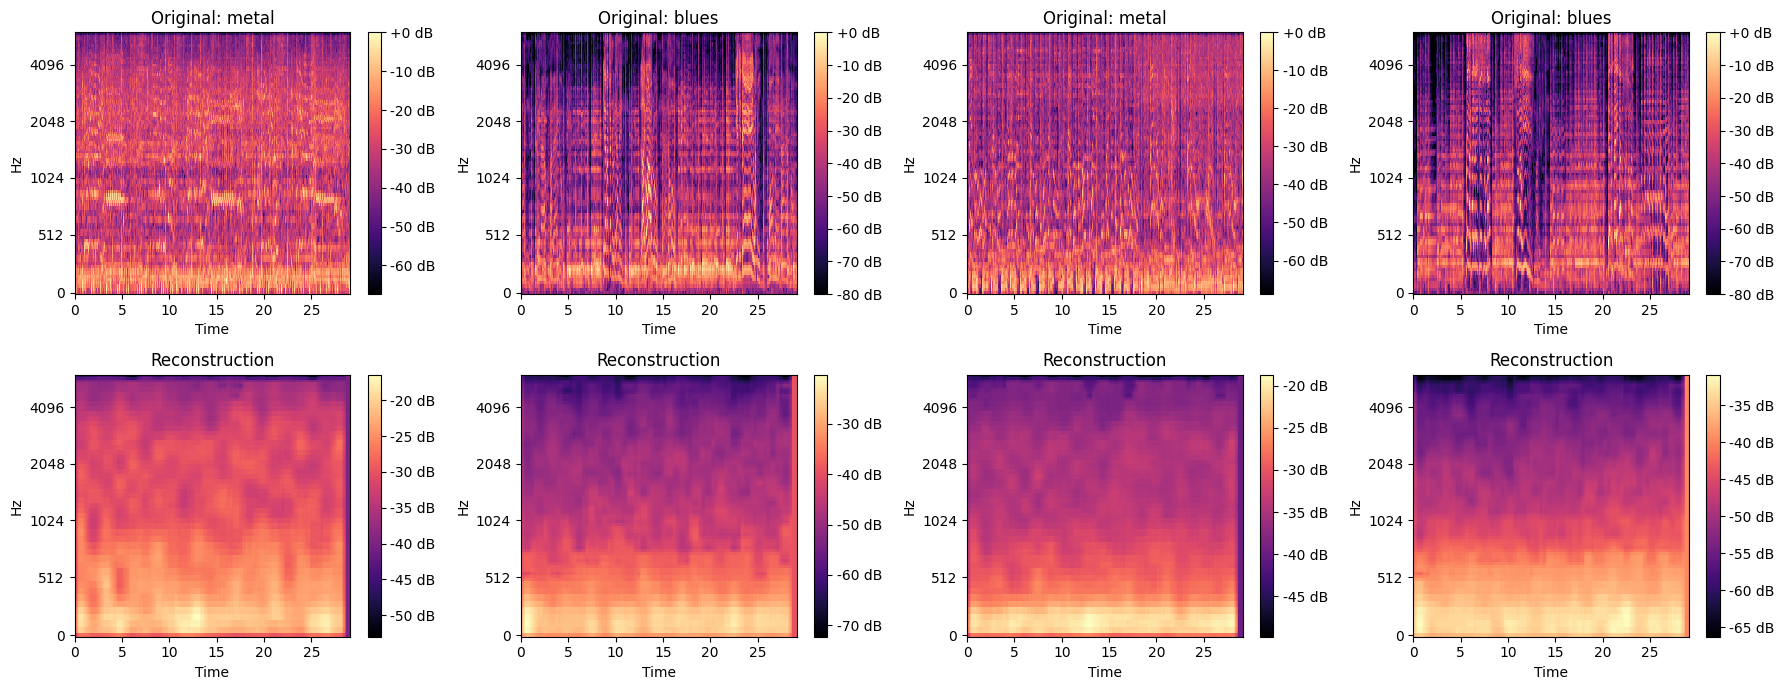

In [21]:
# Visualize reconstruction quality on validation examples
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device, weights_only=True))
model.eval()

mels, labels = next(iter(val_loader))
mels = mels.to(device)
with torch.no_grad():
    recon, _, _ = model(mels)

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for i in range(4):
    orig = (mels[i, 0].cpu().numpy() * mel_std) + mel_mean
    rec = (recon[i, 0].cpu().numpy() * mel_std) + mel_mean
    genre = idx_to_genre[int(labels[i])]
    for ax, data, title in zip(axes[:, i], [orig, rec], [f'Original: {genre}', 'Reconstruction']):
        img = librosa.display.specshow(data, x_axis='time', y_axis='mel', sr=SAMPLE_RATE, hop_length=HOP_LENGTH, ax=ax)
        ax.set_title(title)
        fig.colorbar(img, ax=ax, format='%+2.0f dB')

plt.tight_layout()
plt.show()


In [22]:
@torch.no_grad()
def collect_embeddings(loader):
    model.eval()
    embeddings = []
    labels = []
    for mels, batch_labels in tqdm(loader, desc='Extracting embeddings'):
        z = model.encode(mels.to(device))
        embeddings.append(z.cpu().numpy())
        labels.append(batch_labels.numpy())
    return np.concatenate(embeddings, axis=0), np.concatenate(labels, axis=0)


train_embeddings, train_labels = collect_embeddings(train_loader)
val_embeddings, val_labels = collect_embeddings(val_loader)
test_embeddings, test_labels = collect_embeddings(test_loader)

print(f'Train embeddings: {train_embeddings.shape}')
print(f'Val embeddings:   {val_embeddings.shape}')
print(f'Test embeddings:  {test_embeddings.shape}')

Extracting embeddings: 100%|██████████| 13/13 [00:01<00:00,  8.21it/s]

Train embeddings: (639, 128)
Val embeddings:   (160, 128)
Test embeddings:  (200, 128)


In [23]:
@torch.no_grad()
def classifier_accuracy(model, loader):
    model.eval()
    correct, total = 0, 0
    for mels, labels in loader:
        mels = mels.to(device)
        labels = labels.to(device)
        _, _, logits = model(mels)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return correct / total


# Quantitative latent-space checks
classifier_acc = classifier_accuracy(model, test_loader)

probe = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
probe.fit(train_embeddings, train_labels)
probe_pred = probe.predict(test_embeddings)
probe_acc = accuracy_score(test_labels, probe_pred)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(train_embeddings, train_labels)
knn_pred = knn.predict(test_embeddings)
knn_acc = accuracy_score(test_labels, knn_pred)

all_embeddings = np.concatenate([train_embeddings, val_embeddings, test_embeddings], axis=0)
all_labels = np.concatenate([train_labels, val_labels, test_labels], axis=0)
sil_score = silhouette_score(all_embeddings, all_labels)

metrics_df = pd.DataFrame([
    {'metric': 'classifier_test_accuracy', 'value': classifier_acc},
    {'metric': 'linear_probe_test_accuracy', 'value': probe_acc},
    {'metric': 'knn_5_test_accuracy', 'value': knn_acc},
    {'metric': 'latent_silhouette_score', 'value': sil_score},
    {'metric': 'best_val_reconstruction_mse', 'value': best_val_recon},
])
display(metrics_df)

print('Built-in classifier report (test):')
cls_preds, cls_true = [], []
with torch.no_grad():
    for mels, labels in test_loader:
        _, _, logits = model(mels.to(device))
        cls_preds.extend(logits.argmax(dim=1).cpu().numpy())
        cls_true.extend(labels.numpy())
print(classification_report(cls_true, cls_preds, target_names=genres))


,metric,value
0,classifier_test_accuracy,0.545000
1,linear_probe_test_accuracy,0.585000
2,knn_5_test_accuracy,0.570000
3,latent_silhouette_score,0.045803
4,best_val_reconstruction_mse,0.499472


Built-in classifier report (test):
              precision    recall  f1-score   support

       blues       0.59      0.50      0.54        20
   classical       0.88      0.75      0.81        20
     country       0.45      0.65      0.53        20
       disco       0.33      0.45      0.38        20
      hiphop       0.42      0.25      0.31        20
        jazz       0.41      0.85      0.56        20
       metal       0.75      0.75      0.75        20
         pop       0.83      0.50      0.62        20
      reggae       0.69      0.55      0.61        20
        rock       0.44      0.20      0.28        20

    accuracy                           0.55       200
   macro avg       0.58      0.55      0.54       200
weighted avg       0.58      0.55      0.54       200



PCA variance explained: 70.8%


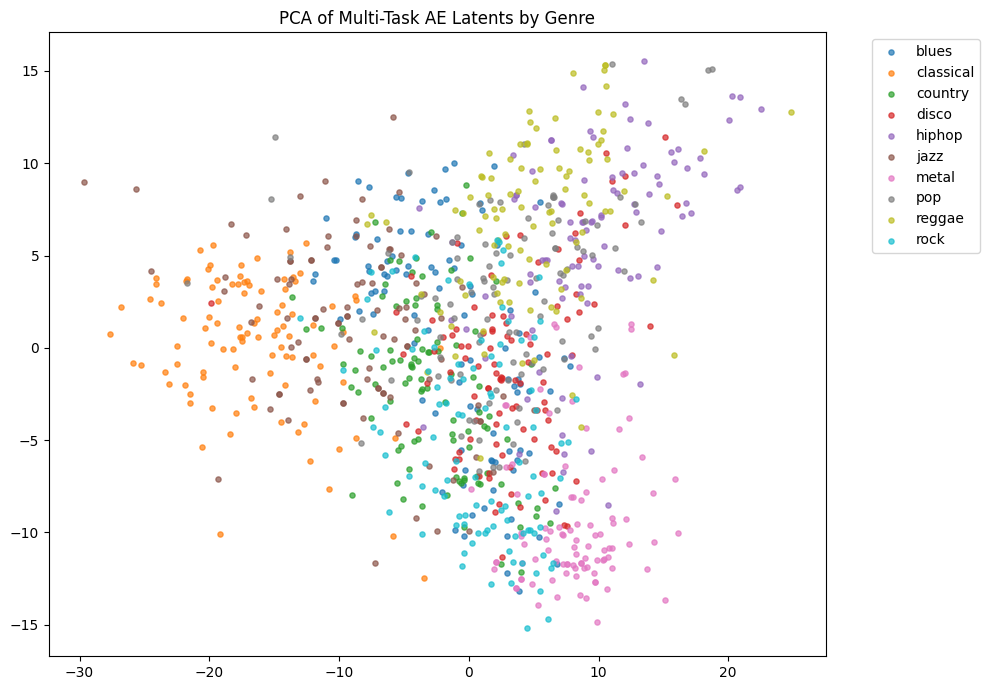

/Users/colbywatts/Documents/College/Spring 2026/CSC 566/csc-566-final-project/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


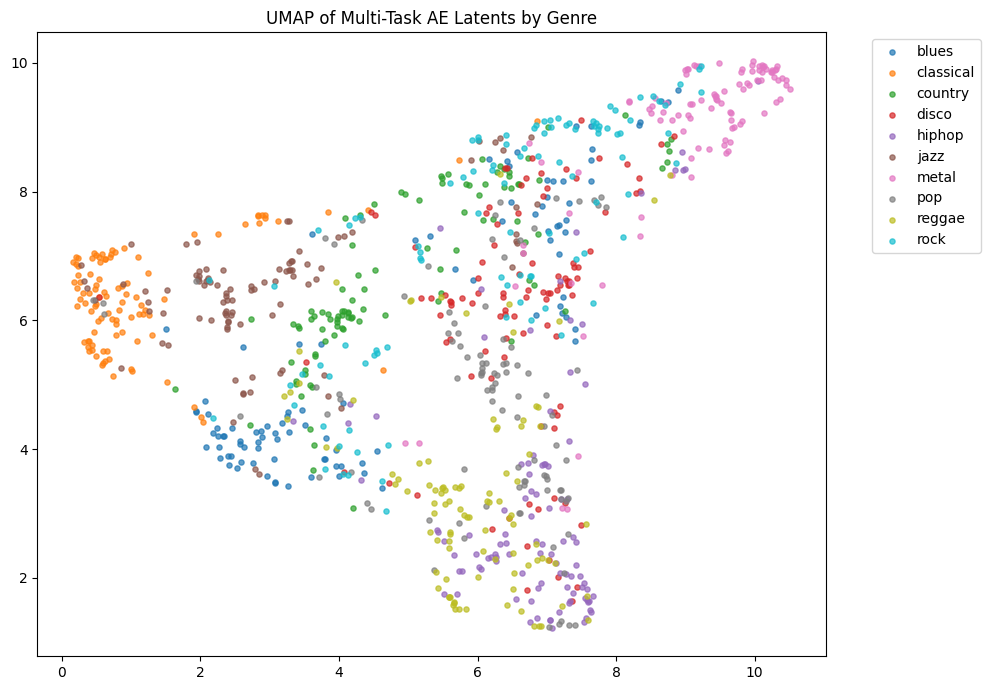

In [24]:
# PCA / UMAP latent visualizations colored by genre
def plot_embedding_2d(points, labels, title):
    plt.figure(figsize=(10, 7))
    for genre_idx, genre in idx_to_genre.items():
        mask = labels == genre_idx
        plt.scatter(points[mask, 0], points[mask, 1], s=14, alpha=0.7, label=genre)
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_points = pca.fit_transform(all_embeddings)
print(f'PCA variance explained: {pca.explained_variance_ratio_.sum() * 100:.1f}%')
plot_embedding_2d(pca_points, all_labels, 'PCA of Multi-Task AE Latents by Genre')

reducer = umap.UMAP(n_components=2, n_neighbors=20, min_dist=0.1, random_state=RANDOM_STATE)
umap_points = reducer.fit_transform(all_embeddings)
plot_embedding_2d(umap_points, all_labels, 'UMAP of Multi-Task AE Latents by Genre')
